In [ ]:
import pandas as pd
import numpy as np

**LOADING THE DATA**

In [ ]:
email=pd.read_csv('/content/email_table.csv')
opened=pd.read_csv('/content/email_opened_table.csv')
clicked=pd.read_csv('/content/link_clicked_table.csv')

In [ ]:
email.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases
0,85120,short_email,personalized,2,Sunday,US,5
1,966622,long_email,personalized,12,Sunday,UK,2
2,777221,long_email,personalized,11,Wednesday,US,2
3,493711,short_email,generic,6,Monday,UK,1
4,106887,long_email,generic,14,Monday,US,6


In [ ]:
opened.head()

,email_id
0,284534
1,609056
2,220820
3,905936
4,164034


In [ ]:
clicked.head()

,email_id
0,609056
1,870980
2,935124
3,158501
4,177561


In [ ]:
print(email.shape)
print(opened.shape)
print(clicked.shape)

(100000, 7)
(10345, 1)
(2119, 1)


In [ ]:
email.isnull().sum()

,0
email_id,0
email_text,0
email_version,0
hour,0
weekday,0
user_country,0
user_past_purchases,0


This helps the ML model train efficiently because the missing values exist everywhere. This is a huge problem in Machine Learning because ML models usually cannot handle missing datas properly.

In [ ]:
open_rate=(len(opened) / len(email)) * 100
print("Open Rate:", round(open_rate,2), "%")

Open Rate: 10.35 %


In [ ]:
ctr=(len(clicked) / len(email)) * 100
print("Click Through Rate:", round(ctr,2), "%")

Click Through Rate: 2.12 %


In [ ]:
email['clicked']=email['email_id'].isin(clicked['email_id']).astype(int)

This creates a new column called clicked in the email table. It checks whether each email_id from the email dataset exists in the clicked dataset. If it exist, that means user has clicked the link so it assigns 1, otherwise 0.

In [ ]:
email.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases,clicked
0,85120,short_email,personalized,2,Sunday,US,5,0
1,966622,long_email,personalized,12,Sunday,UK,2,1
2,777221,long_email,personalized,11,Wednesday,US,2,0
3,493711,short_email,generic,6,Monday,UK,1,0
4,106887,long_email,generic,14,Monday,US,6,0


**BASIC ANALYSIS:** This part will return the click rate of the various email categories. The purpose of calculating click rates for different email categories is to identify which email characteristics, user attributes and campaign settings are associated with higher engagement so that the company can optimize future email campaigns.

Personalized vs Generic:

In [ ]:
email.groupby('email_version')['clicked'].mean()*100

,clicked
email_version,
generic,1.513673
personalized,2.729409


Long vs Short Email:

In [ ]:
email.groupby('email_text')['clicked'].mean()*100

,clicked
email_text,
long_email,1.853767
short_email,2.387177


Weekday Analysis:

In [ ]:
email.groupby('weekday')['clicked'].mean()*100

,clicked
weekday,
Friday,1.403682
Monday,2.290608
Saturday,1.784611
Sunday,1.675123
Thursday,2.444491
Tuesday,2.488864
Wednesday,2.761999


Hour Analysis:

In [ ]:
email.groupby('hour')['clicked'].mean()*100

,clicked
hour,
1,1.812801
2,1.632209
3,1.952278
4,1.618641
5,1.801252
6,1.714668
7,1.828376
8,1.893308
9,2.579435


Country Analysis:

In [ ]:
email.groupby('user_country')['clicked'].mean()*100

,clicked
user_country,
ES,0.832748
FR,0.800400
UK,2.467526
US,2.435981


**DATA VISUALIZATION**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

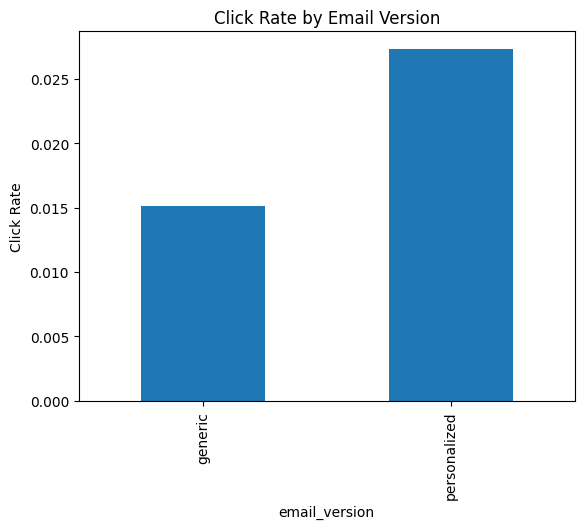

In [ ]:
email.groupby('email_version')['clicked'].mean().plot(kind='bar')

plt.ylabel("Click Rate")
plt.title("Click Rate by Email Version")
plt.show()

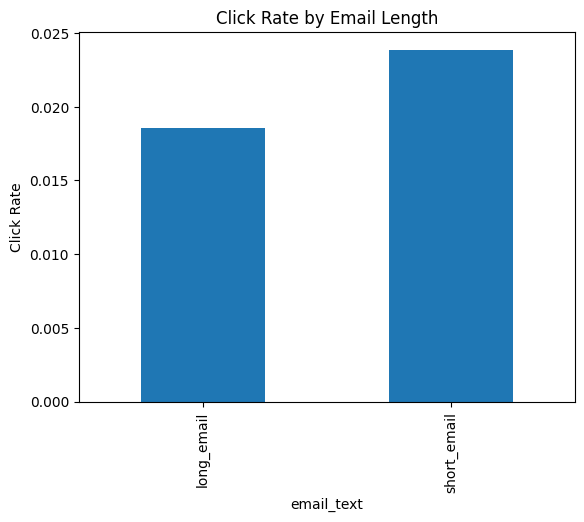

In [ ]:
email.groupby('email_text')['clicked'].mean().plot(kind='bar')

plt.ylabel("Click Rate")
plt.title("Click Rate by Email Length")
plt.show()

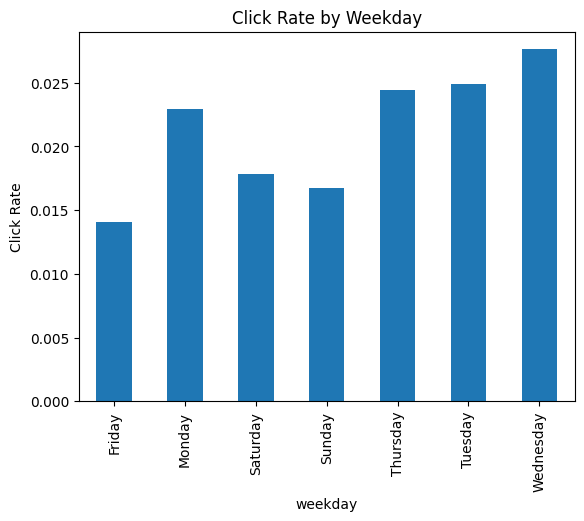

In [ ]:
email.groupby('weekday')['clicked'].mean().plot(kind='bar')

plt.ylabel("Click Rate")
plt.title("Click Rate by Weekday")
plt.show()

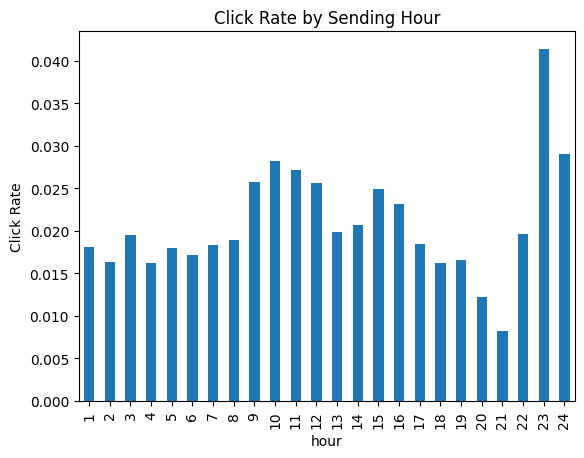

In [ ]:
email.groupby('hour')['clicked'].mean().plot(kind='bar')

plt.ylabel("Click Rate")
plt.title("Click Rate by Sending Hour")
plt.show()

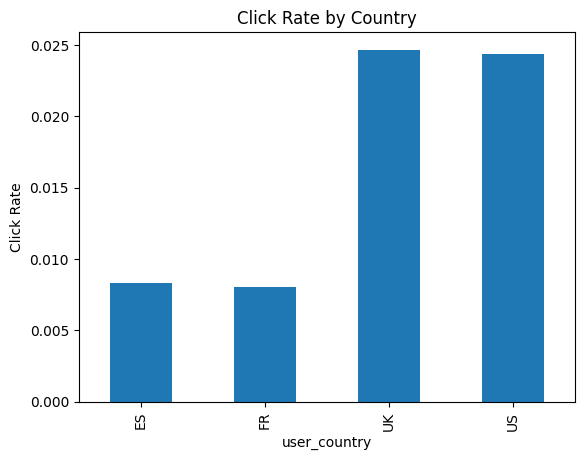

In [ ]:
email.groupby('user_country')['clicked'].mean().plot(kind='bar')

plt.ylabel("Click Rate")
plt.title("Click Rate by Country")
plt.show()

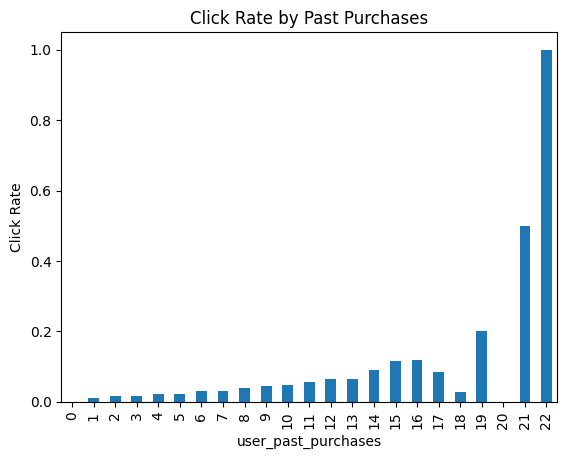

In [ ]:
email.groupby('user_past_purchases')['clicked'].mean().plot(kind='bar')

plt.ylabel("Click Rate")
plt.title("Click Rate by Past Purchases")
plt.show()

**MACHINE LEARNING MODEL**

In [ ]:
data=email.copy()

In [ ]:
data=pd.get_dummies(data, drop_first=True)

This line is used to convert the categorical(text) columns into numerical columns using one-hot encoding because a ML model cannot understand texts.

In [ ]:
X=data.drop(['email_id','clicked'], axis=1)
y=data['clicked']

These two lines are used to split the dataset into-
*   X=Features(inputs)
*   y=Target(answers)
---
When we train the model, we are simply telling the model-

*   These are the features(X)
*   These are the correct answers(Y)
*   Now figure out the relationship, so the model does see the clicked values during training and that's how it learns







In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model=RandomForestClassifier(random_state=42)

In [ ]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
predictions=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 0.97455


In [ ]:
importance=pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance=importance.sort_values(by='Importance',ascending=False)

importance.head(10)

,Feature,Importance
0,hour,0.459203
1,user_past_purchases,0.371352
2,email_text_short_email,0.032536
3,email_version_personalized,0.020092
11,user_country_UK,0.016125
4,weekday_Monday,0.015294
8,weekday_Tuesday,0.014424
7,weekday_Thursday,0.013662
5,weekday_Saturday,0.013204
12,user_country_US,0.012943


**IMPROVEMENT STARTEGY**

Instead of sending emails randomly, the company can use the machine learning model to identify users with higher probability of clicking the email link.

This allows the company to target only high-interest users, improving click through rate and reducing unnecessary emails.

The model can especially help identify:
- users with higher past purchases
- users from high-performing countries
- best email versions
- optimal sending times

**HOW IS THE MODEL TESTED**

The effectiveness of the model can be tested using A/B Testing.

Group A:
Randomly selected users receive emails.

Group B:
Users selected using the machine learning model receive emails.

The click through rates of both groups can then be compared.

If Group B achieves higher CTR, the model is successful.

**FINAL INSIGHTS**

Interesting Patterns Observed:

1. Personalized emails performed better than generic emails.
2. Certain weekdays and hours had higher click rates.
3. Users with higher past purchases were more likely to click.
4. Email performance varied across countries.
5. Short or long emails may perform differently depending on user behavior.